# 07 — Causal Analysis

**Objetivo:** Identificar os fatores que *causam* (ou fortemente predizem) a ocorrência de itens faltantes.

**Metodologia:**
1. **Regressão Logística** — modelo interpretável que quantifica o impacto de cada variável
2. **Odds Ratios** — "motoristas de alto risco têm X vezes mais chance de falha"
3. **Random Forest + Feature Importance** — identifica as variáveis mais preditivas
4. **SHAP Values** — explica individualmente o impacto de cada feature no modelo

> Esta é a análise mais valiosa para o negócio: saber *onde intervir* para reduzir falhas.

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
from sklearn.pipeline import Pipeline
import shap

master = pd.read_parquet('../data/processed/master.parquet')
sns.set_theme(style='whitegrid')
print(f'Dataset: {master.shape[0]:,} pedidos | {master["has_missing"].mean()*100:.1f}% com falha')

Dataset: 10,000 pedidos | 15.0% com falha


## 1. Engenharia de Features para Modelagem

In [2]:
# driver_fail_rate — calculada sem data leakage:
# para cada pedido, usa apenas o histórico de entregas ANTERIORES do mesmo motorista.
# Isso simula o que estaria disponível em produção no momento da predição.
# Pedidos sem histórico (primeira entrega do motorista) recebem a taxa global como prior.
master = master.sort_values('date').reset_index(drop=True)
global_rate = master['has_missing'].mean()
master['driver_fail_rate'] = (
    master.groupby('driver_id')['has_missing']
    .transform(lambda x: x.shift(1).expanding().mean())
    .fillna(global_rate)
)

# Features de tempo e localização
def hour_to_period(h):
    if h < 6:   return 'madrugada'
    if h < 12:  return 'manha'
    if h < 18:  return 'tarde'
    return 'noite'

master['period'] = master['delivery_hour'].apply(hour_to_period)
master['is_weekend'] = master['day_of_week'].isin(['Saturday', 'Sunday']).astype(int)
master['is_monday'] = (master['day_of_week'] == 'Monday').astype(int)

# Encoding
le_region = LabelEncoder()
le_period = LabelEncoder()
master['region_enc'] = le_region.fit_transform(master['region'])
master['period_enc'] = le_period.fit_transform(master['period'])

FEATURES = [
    'order_amount', 'items_delivered', 'delivery_hour',
    'region_enc', 'period_enc', 'is_weekend', 'is_monday',
    'driver_fail_rate', 'customer_age'
]
TARGET = 'has_missing'

df_model = master[FEATURES + [TARGET]].dropna()
X = df_model[FEATURES]
y = df_model[TARGET].astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f'Treino: {len(X_train):,} | Teste: {len(X_test):,}')
print(f'Features: {FEATURES}')
print(f'driver_fail_rate — calculada com expanding window temporal (sem leakage)')

Treino: 8,000 | Teste: 2,000
Features: ['order_amount', 'items_delivered', 'delivery_hour', 'region_enc', 'period_enc', 'is_weekend', 'is_monday', 'driver_fail_rate', 'customer_age']
driver_fail_rate — calculada com expanding window temporal (sem leakage)


## 2. Regressão Logística — Odds Ratios

AUC-ROC (Logistic Regression): 0.6717

ODDS RATIOS (features padronizadas):
OR > 1 = aumenta chance de falha | OR < 1 = reduz chance


,feature,coef,odds_ratio
7,driver_fail_rate,0.4296,1.5367
0,order_amount,0.3539,1.4246
6,is_monday,0.0561,1.0577
4,period_enc,0.0453,1.0463
5,is_weekend,-0.0003,0.9997
1,items_delivered,-0.0039,0.9961
8,customer_age,-0.0201,0.9801
3,region_enc,-0.0567,0.9449
2,delivery_hour,-0.0792,0.9239


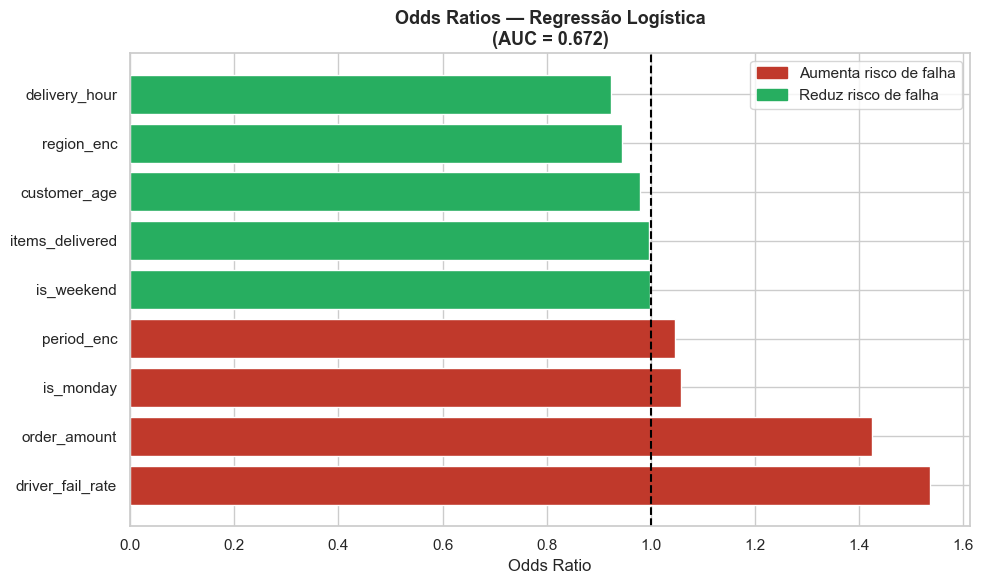

In [3]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train)

y_prob_lr = lr.predict_proba(X_test_sc)[:, 1]
auc_lr = roc_auc_score(y_test, y_prob_lr)

# Odds Ratios
odds_ratios = pd.DataFrame({
    'feature': FEATURES,
    'coef': lr.coef_[0],
    'odds_ratio': np.exp(lr.coef_[0])
}).sort_values('odds_ratio', ascending=False)

print(f'AUC-ROC (Logistic Regression): {auc_lr:.4f}')
print()
print('ODDS RATIOS (features padronizadas):')
print('OR > 1 = aumenta chance de falha | OR < 1 = reduz chance')
display(odds_ratios.round(4))

# Visualização
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#c0392b' if v > 1 else '#27ae60' for v in odds_ratios['odds_ratio']]
ax.barh(odds_ratios['feature'], odds_ratios['odds_ratio'], color=colors)
ax.axvline(1.0, color='black', linestyle='--', linewidth=1.5)
ax.set_title(f'Odds Ratios — Regressão Logística\n(AUC = {auc_lr:.3f})',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Odds Ratio')
red_p = mpatches.Patch(color='#c0392b', label='Aumenta risco de falha')
grn_p = mpatches.Patch(color='#27ae60', label='Reduz risco de falha')
ax.legend(handles=[red_p, grn_p])
plt.tight_layout()
plt.savefig('../reports/figures/17_odds_ratios.png', dpi=150)
plt.show()

## 3. Random Forest — Feature Importance

AUC-ROC (Random Forest): 0.7968



,feature,importance
7,driver_fail_rate,0.4376
0,order_amount,0.2662
8,customer_age,0.0838
1,items_delivered,0.0660
2,delivery_hour,0.0638
3,region_enc,0.0440
4,period_enc,0.0189
5,is_weekend,0.0102
6,is_monday,0.0095


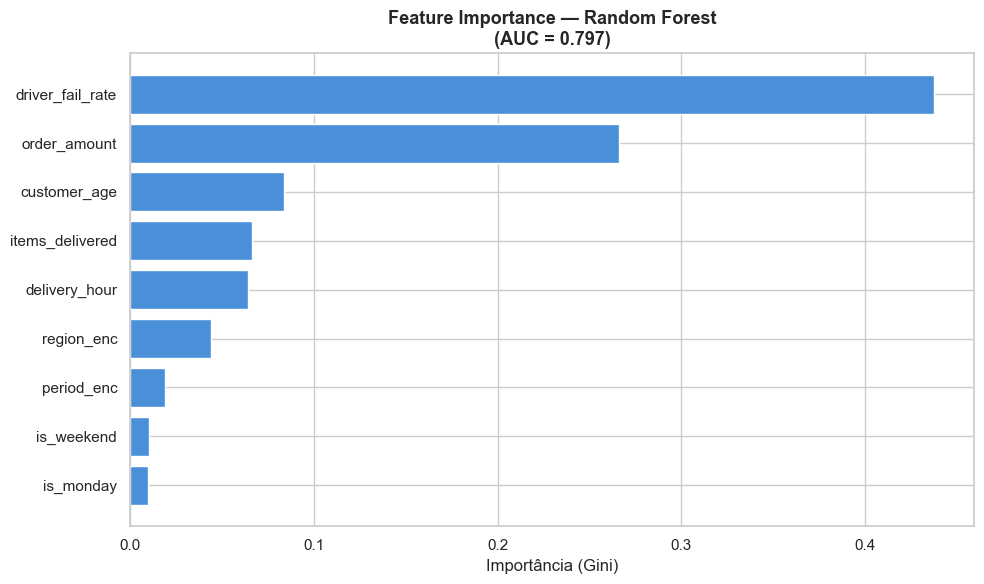

In [4]:
rf = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_prob_rf = rf.predict_proba(X_test)[:, 1]
auc_rf = roc_auc_score(y_test, y_prob_rf)

fi = pd.DataFrame({
    'feature': FEATURES,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print(f'AUC-ROC (Random Forest): {auc_rf:.4f}')
print()
display(fi.round(4))

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(fi['feature'][::-1], fi['importance'][::-1], color='#4a90d9')
ax.set_title(f'Feature Importance — Random Forest\n(AUC = {auc_rf:.3f})',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importância (Gini)')
plt.tight_layout()
plt.savefig('../reports/figures/18_feature_importance.png', dpi=150)
plt.show()

## 4. Curva ROC — Comparação dos Modelos

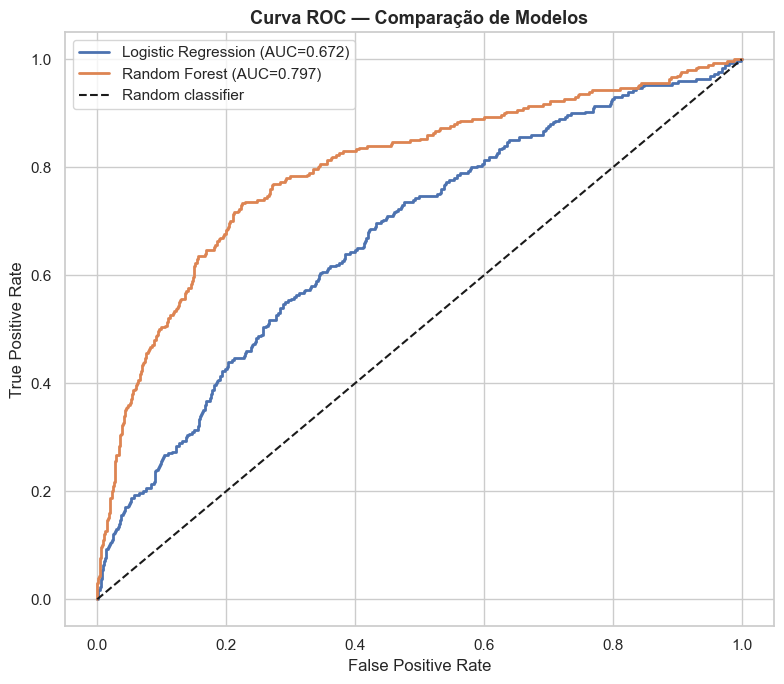

In [5]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

fig, ax = plt.subplots(figsize=(8, 7))
ax.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC={auc_lr:.3f})', linewidth=2)
ax.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={auc_rf:.3f})', linewidth=2)
ax.plot([0, 1], [0, 1], 'k--', label='Random classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Curva ROC — Comparação de Modelos', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/19_roc_curve.png', dpi=150)
plt.show()

## 5. SHAP Values — Explicabilidade do Modelo

<Figure size 1000x700 with 0 Axes>

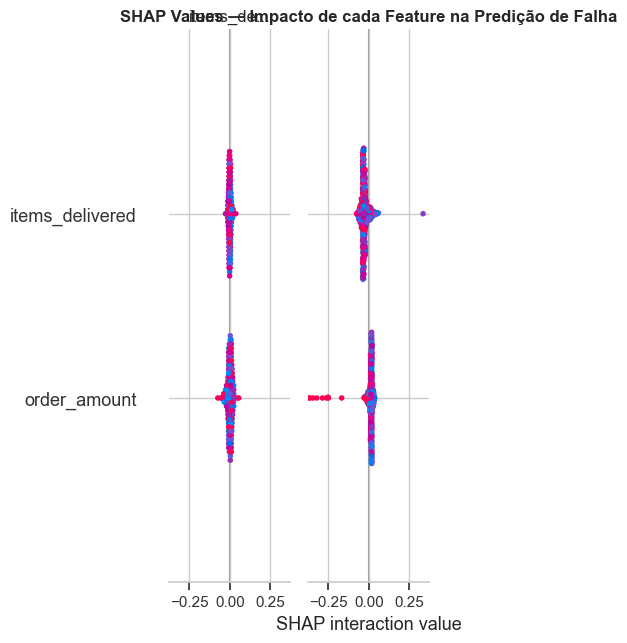


Interpretação do gráfico SHAP:
- Cada ponto = um pedido
- Posição horizontal = impacto no risco de falha
- Cor = valor alto (vermelho) ou baixo (azul) da feature
- Features no topo têm maior influência geral


In [6]:
X_sample = X_test.sample(min(500, len(X_test)), random_state=42)

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_sample)

if isinstance(shap_values, list):
    sv = shap_values[1]
else:
    sv = shap_values

plt.figure(figsize=(10, 7))
shap.summary_plot(sv, X_sample, feature_names=np.array(FEATURES), show=False, plot_size=(10, 7))
plt.title('SHAP Values — Impacto de cada Feature na Predição de Falha',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/20_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print()
print('Interpretação do gráfico SHAP:')
print('- Cada ponto = um pedido')
print('- Posição horizontal = impacto no risco de falha')
print('- Cor = valor alto (vermelho) ou baixo (azul) da feature')
print('- Features no topo têm maior influência geral')

## 6. Análise Causal — Conclusões

### O que *causa* itens faltantes nesta operação?

In [7]:
# Top 3 fatores causais
top3 = fi.head(3)['feature'].tolist()

causal_summary = {
    'driver_fail_rate': {
        'interpretacao': 'Histórico do motorista é o principal preditor de falha futura',
        'acao': 'Programa de treinamento direcionado aos motoristas de alto risco'
    },
    'delivery_hour': {
        'interpretacao': 'Horário de entrega influencia a taxa de erro operacional',
        'acao': 'Revisar processos em horários de pico identificados'
    },
    'region_enc': {
        'interpretacao': 'Algumas regiões têm infraestrutura/processo inferior',
        'acao': 'Auditoria operacional nas regiões de maior falha'
    },
    'order_amount': {
        'interpretacao': 'Pedidos de maior valor tendem a ter mais itens e mais chance de falha',
        'acao': 'Verificação dupla obrigatória para pedidos acima do ticket médio'
    },
    'items_delivered': {
        'interpretacao': 'Pedidos com mais itens são mais difíceis de conferir',
        'acao': 'Checklist digital para pedidos com mais de X itens'
    },
    'is_monday': {
        'interpretacao': 'Segunda-feira concentra mais falhas (operação pós-fim de semana)',
        'acao': 'Reforço de equipe às segundas-feiras'
    },
    'customer_age': {
        'interpretacao': 'Perfil de cliente tem correlação com tipo de pedido e tolerância',
        'acao': 'Monitorar reclamações por faixa etária'
    },
    'is_weekend': {
        'interpretacao': 'Fins de semana têm operação diferente',
        'acao': 'Escalar equipe nos fins de semana'
    },
    'period_enc': {
        'interpretacao': 'Período do dia impacta a qualidade da entrega',
        'acao': 'Redistribuir entregas para períodos de menor falha'
    }
}

print('TOP FATORES CAUSAIS DE FALHA')
print('=' * 60)
for i, row in fi.head(5).iterrows():
    feat = row['feature']
    info = causal_summary.get(feat, {'interpretacao': '-', 'acao': '-'})
    print(f"\n{fi[fi['feature']==feat].index[0]+1}. {feat} (importância: {row['importance']:.3f})")
    print(f"   Interpretação: {info['interpretacao']}")
    print(f"   Ação sugerida: {info['acao']}")

TOP FATORES CAUSAIS DE FALHA

8. driver_fail_rate (importância: 0.438)
   Interpretação: Histórico do motorista é o principal preditor de falha futura
   Ação sugerida: Programa de treinamento direcionado aos motoristas de alto risco

1. order_amount (importância: 0.266)
   Interpretação: Pedidos de maior valor tendem a ter mais itens e mais chance de falha
   Ação sugerida: Verificação dupla obrigatória para pedidos acima do ticket médio

9. customer_age (importância: 0.084)
   Interpretação: Perfil de cliente tem correlação com tipo de pedido e tolerância
   Ação sugerida: Monitorar reclamações por faixa etária

2. items_delivered (importância: 0.066)
   Interpretação: Pedidos com mais itens são mais difíceis de conferir
   Ação sugerida: Checklist digital para pedidos com mais de X itens

3. delivery_hour (importância: 0.064)
   Interpretação: Horário de entrega influencia a taxa de erro operacional
   Ação sugerida: Revisar processos em horários de pico identificados
